In [1]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import plotly.express as px

In [2]:
from src.jax_resnet.model import init_params, FiniteResNetParams, relu, batched_forward_track
from src.jax_resnet.training import train_scan_jit, train_dropout_scan_jit, train_ram_scan_jit, train_scan_ce_jit, train_dropout_scan_ce_jit, train_ram_scan_ce_jit

In [3]:
from src.utils import make_dataset_mnist, align_tracked_particle_across_layers

In [4]:
d_in, d_out, seed = 784, 2, 42
N=100
X_train, Y_train, X_test, Y_test = make_dataset_mnist(N=N, seed=seed, digits=[4,7])

In [5]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((80, 784), (80, 2), (20, 784), (20, 2))

In [6]:
D, L, M = 10, 4, 8
tau = 0.4
n_steps = 200
lr_in, lr_out = 0.0, 0.0
q = 0.5
batch_size = 64
last_particle_single_source = True

num_repetitions = 5
LOOP_SEED = 48

In [7]:
params0 = init_params(random.PRNGKey(seed + 44), d_in, d_out, D, L, M)
params0 = align_tracked_particle_across_layers(params0, particle_idx=-1)

In [8]:
import pickle

setting_str = f'L{L}_M{M}_D{D}_tau{tau}_q{q}_nsteps{n_steps}_din{d_in}_dout{d_out}_seed{seed}_N{N}_numrepetitions{num_repetitions}_loopseed{LOOP_SEED}_batchsize{batch_size}_lpss{last_particle_single_source}'


# Export (serialize) to pickle
with open(f'data/mnist/final_params_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_gd = pickle.load(f)

with open(f'data/mnist/histories_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_gd = pickle.load(f)

with open(f'data/mnist/final_params_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_do = pickle.load(f)

with open(f'data/mnist/histories_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_do = pickle.load(f)

with open(f'data/mnist/final_params_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_ram = pickle.load(f)

with open(f'data/mnist/histories_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_ram = pickle.load(f)


In [9]:
def get_predictions(output):
    if isinstance(output, dict):
        return output["test_output"].argmax(axis=-1)
    return output.argmax(axis=-1)

In [10]:
def plot_test_images(X_test, Y_test, prediction, n_rows=3, n_cols=4):
    n_show = n_rows * n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 9))
    axes = axes.ravel()

    # Support both one-hot and integer ground-truth labels.
    if getattr(Y_test, "ndim", 1) > 1:
        y_true = np.asarray(Y_test).argmax(axis=-1)
    else:
        y_true = np.asarray(Y_test)

    y_pred = np.asarray(prediction)

    for i in range(n_show):
        ax = axes[i]
        ax.imshow(np.asarray(X_test[i]).reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[i]} | GT: {y_true[i]}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

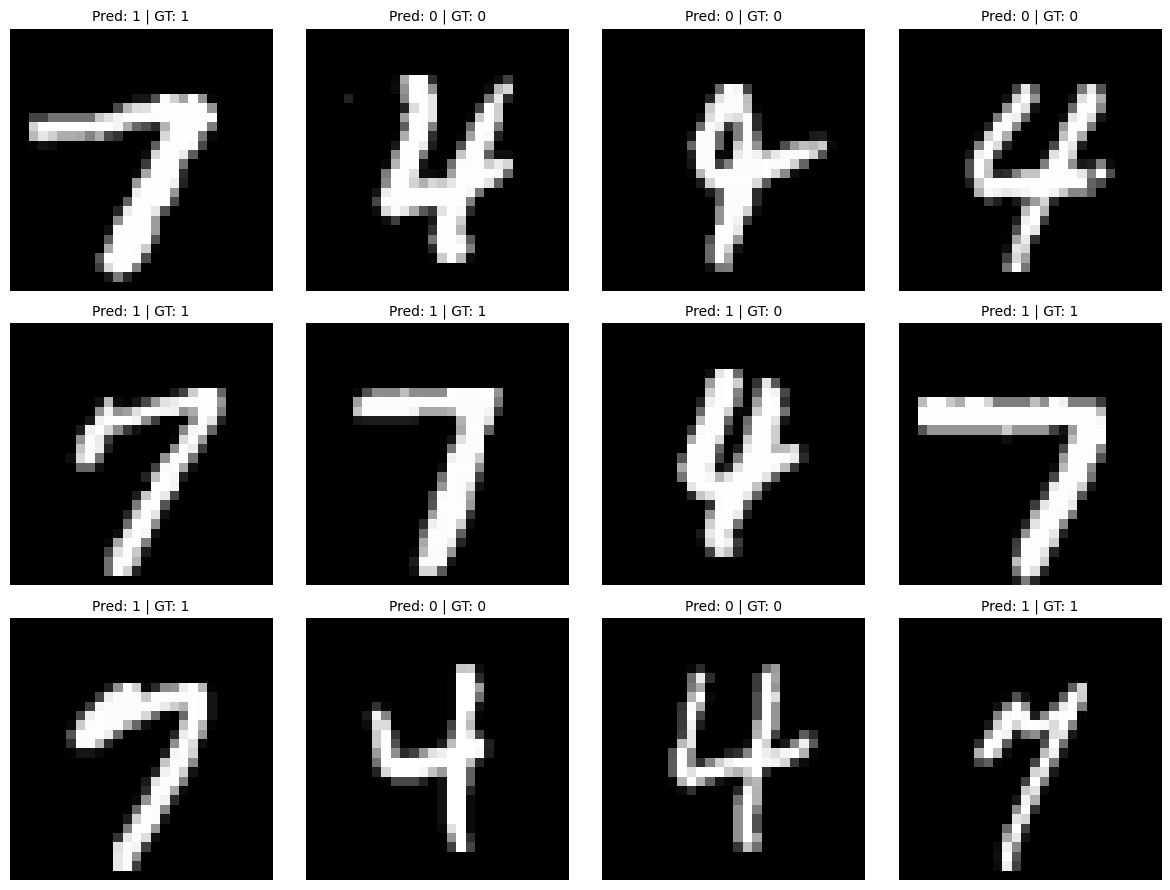

In [11]:
predictions = get_predictions(histories_do["full_unit_dropout"][0]["test_output"])
plot_test_images(X_test, Y_test, predictions)

In [12]:
def compute_accuracy(predictions, Y_test):
    return 1- jnp.abs(predictions - Y_test.argmax(axis=1)).sum()/Y_test.shape[0]

In [13]:
predictions_do1 = get_predictions(histories_do["full_unit_dropout"][0])
predictions_ram1 = get_predictions(histories_ram["full_unit_dropout"][0])
predictions_do2 = get_predictions(histories_do["stochastic_depth"][0])
predictions_ram2 = get_predictions(histories_ram["stochastic_depth"][0])
predictions_gd = get_predictions(histories_gd["gd"][0])

In [14]:

print(compute_accuracy(predictions_do1, Y_test))
print(compute_accuracy(predictions_ram1, Y_test))
print(compute_accuracy(predictions_do2, Y_test))
print(compute_accuracy(predictions_ram2, Y_test))
print(compute_accuracy(predictions_gd, Y_test))

0.9
0.8
0.9
0.95
0.8


In [15]:
# Compare test loss across GD, Dropout and RaM for selected variants

def plot_test_loss_compare_all_runs(show=True, xlim=None, ylim=None):
    """Plot mean ± std of test loss over iterations for GD, full_unit, and stochastic_depth runs."""
    run_specs = {
        'GD': histories_gd["gd"],
        'Dropout (full-unit)': histories_do["full_unit_dropout"],
        'RaM (full-unit)': histories_ram["full_unit_dropout"],
        'Dropout (stochastic depth)': histories_do["stochastic_depth"],
        'RaM (stochastic depth)': histories_ram["stochastic_depth"],
        'Dropout (depth shared)': histories_do["single_source_M"],
        'RaM (depth shared)': histories_ram["single_source_M"],
    }
    run_colors = {
        'GD': 'black',
        'Dropout (full-unit)': 'tab:blue',
        'RaM (full-unit)': 'tab:blue',
        'Dropout (stochastic depth)': 'tab:green',
        'RaM (stochastic depth)': 'tab:green',
        'Dropout (depth shared)': 'tab:purple',
        'RaM (depth shared)': 'tab:purple',
    }
    run_linestyles = {
        'GD': '-',
        'Dropout (full-unit)': '--',
        'RaM (full-unit)': '-',
        'Dropout (stochastic depth)': '--',
        'RaM (stochastic depth)': '-',
        'Dropout (depth shared)': '--',
        'RaM (depth shared)': '-',
    }

    steps = np.arange(len(histories_gd["gd"][0]['test_loss']))
    fig, ax = plt.subplots(figsize=(6, 4))

    for run_name, run_history in run_specs.items():
        values = np.stack([np.asarray(h['test_loss']) for h in run_history], axis=0)
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        color = run_colors[run_name]
        linestyle = run_linestyles[run_name]
        ax.plot(steps, mean, label=run_name, color=color, linestyle=linestyle)
        ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

    #ax.set_yscale('log')
    ax.set_title('Test loss comparison')
    ax.set_xlabel('step')
    ax.set_ylabel('test loss')
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=6)

    fig.tight_layout()
    if show:
        plt.show()
    return fig

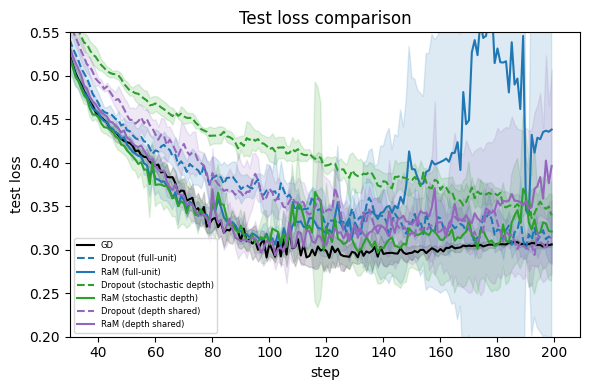

In [16]:
fig = plot_test_loss_compare_all_runs(xlim=(30, None), ylim=(0.2, 0.55))

In [17]:
#fig.savefig(f"plots/mnist_loss_ram_do_all_variants_full_datasetL{L}M{M}.pdf")

In [18]:
def plot_compare_final_params(
        params_list,
        labels,
        params_init=None,
        n_dims=6,
        particle_idx=-1,
        include_v=True,
        show=True,
    ):
        """Plot and compare final U/V parameters across multiple training runs with optional init overlay.

        Args:
            params_list: list of parameter objects (e.g., [params_do, params_ram, params_gd])
            labels: list of labels for legend (e.g., ['dropout', 'ram', 'gd'])
            params_init: optional initial parameters to overlay as dashed lines
            n_dims: number of dimensions to plot
            particle_idx: which particle to extract
            include_v: whether to plot V parameters
            show: whether to display the plot
        """
        color_map = {
            'full-unit': 'tab:blue',
            'stochastic-depth': 'tab:green',
            'depth-shared': 'tab:purple',
            'gd': 'black',
        }
        linestyle_map = {
            'dropout': '--',
            'ram': '-',
            'gd': '-',
        }

        # Extract U and V from all params
        param_data = []
        for params in params_list:
            param_data.append((np.asarray(params.U), np.asarray(params.V)))

        U_init, V_init = None, None
        if params_init is not None:
            U_init, V_init = np.asarray(params_init.U), np.asarray(params_init.V)

        L, _, D = param_data[0][0].shape
        n_dims = int(min(n_dims, D))
        layer_idx = np.arange(L)
        selected_dims = np.arange(n_dims)
        n_rows = 2 if include_v else 1
        _fig, axes = plt.subplots(n_rows, n_dims, figsize=(3.6 * n_dims, 3.2 * n_rows), sharex=True, squeeze=False)

        for col, d in enumerate(selected_dims):
            # Plot U
            ax_u = axes[0, col]
            if U_init is not None:
                ax_u.plot(layer_idx, U_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='initialization' if col == 0 else None)
            for (u_arr, _), label in zip(param_data, labels):
                label_lower = label.lower()
                color = 'black' if 'gd' in label_lower else color_map.get(next((k for k in color_map if k in label_lower), 'gd'), 'black')
                linestyle = linestyle_map['gd'] if 'gd' in label_lower else linestyle_map['ram' if 'ram' in label_lower else 'dropout']
                ax_u.plot(layer_idx, u_arr[:, particle_idx, d], color=color, linewidth=1.6, linestyle=linestyle, label=label if col == 0 else None)
            ax_u.set_title(f'U (coordinate {d})')#(f'U[:, {particle_idx}, {d}]')
            ax_u.grid(alpha=0.2)
            if col == 0:
                ax_u.set_ylabel('U value')
                ax_u.legend(loc='best', fontsize=8)

            # Plot V
            if include_v:
                ax_v = axes[1, col]
                if V_init is not None:
                    ax_v.plot(layer_idx, V_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='initialization' if col == 0 else None)
                for (_, v_arr), label in zip(param_data, labels):
                    label_lower = label.lower()
                    color = 'black' if 'gd' in label_lower else color_map.get(next((k for k in color_map if k in label_lower), 'gd'), 'black')
                    linestyle = linestyle_map['gd'] if 'gd' in label_lower else linestyle_map['ram' if 'ram' in label_lower else 'dropout']
                    ax_v.plot(layer_idx, v_arr[:, particle_idx, d], color=color, linewidth=1.6, linestyle=linestyle, label=label if col == 0 else None)
                ax_v.set_title(f'V (coordinate {d})')#(f'V[:, {particle_idx}, {d}]')
                ax_v.grid(alpha=0.2)
                if col == 0:
                    ax_v.set_ylabel('V value')
                    ax_v.legend(loc='best', fontsize=8)

        for col in range(n_dims):
            axes[-1, col].set_xlabel('layer l')

        _fig.suptitle('U/V comparison across runs', y=1.02)
        _fig.tight_layout()
        if show:
            plt.show()
        return _fig

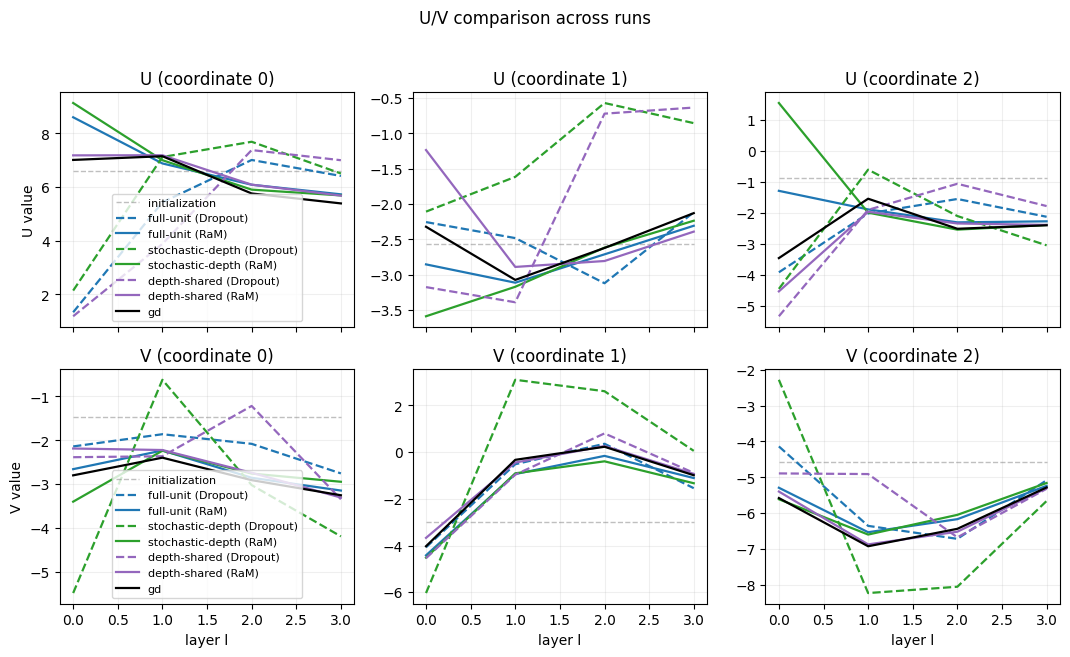

In [19]:
chosen_variant_do1, chosen_variant_ram1 = "full_unit_dropout", "full_unit_dropout"
chosen_variant_do2, chosen_variant_ram2 = "stochastic_depth", "stochastic_depth"
chosen_variant_do3, chosen_variant_ram3 = "single_source_M", "single_source_M"
rep_chosen = 4
comparison_three = plot_compare_final_params(
    [final_params_do[chosen_variant_do1][rep_chosen],
     final_params_ram[chosen_variant_ram1][rep_chosen],
     final_params_do[chosen_variant_do2][rep_chosen],
     final_params_ram[chosen_variant_ram2][rep_chosen],
     final_params_do[chosen_variant_do3][rep_chosen],
     final_params_ram[chosen_variant_ram3][rep_chosen],
     final_params_gd["gd"][rep_chosen]],
    ["full-unit (Dropout)",
     "full-unit (RaM)",
     "stochastic-depth (Dropout)",
     "stochastic-depth (RaM)",
     "depth-shared (Dropout)",
     "depth-shared (RaM)",
     "gd"],
    params_init=params0,
    n_dims=3,
    particle_idx=-1,
    include_v=True,
    show=False,
)

In [20]:
#comparison_three.savefig(f"plots/mnist_params_all_variants{L}M{M}.pdf")